In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge , LinearRegression
from sklearn.metrics import mean_squared_error , r2_score
from sklearn.preprocessing import StandardScaler


In [5]:
from sklearn.datasets import load_diabetes

data = load_diabetes()
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]], shape=(442, 10)),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142.

In [8]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [13]:
# Train test split
X_train, X_test, y_train, y_test = train_test_split(df.drop('target', axis=1), df['target'], test_size=0.2, random_state=42)

# Scaling the data
std = StandardScaler()
X_train_scaled = std.fit_transform(X_train)
X_test_scaled = std.transform(X_test)

# Initializing and fitting the linear regression model
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# Predicting and evaluating the linear regression model
y_pred_lr = lr.predict(X_test_scaled)

# Accuracy of linear regression model
accuracy_r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print(f"Linear Regression R2 Score: {accuracy_r2_lr}")
print(f"Linear Regression MSE: {mse_lr}")

Linear Regression R2 Score: 0.45260276297191915
Linear Regression MSE: 53.85344583676594


In [15]:
# Using Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

# Accuracy of linear regression model
accuracy_r2_lr = r2_score(y_test, y_pred_ridge)
mse_lr = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Linear Regression R2 Score with Ridge Regression: {accuracy_r2_lr}")
print(f"Linear Regression MSE with Ridge Regression: {mse_lr}")

Linear Regression R2 Score with Ridge Regression: 0.45414652070698214
Linear Regression MSE with Ridge Regression: 53.7774540653439


## Reidge Regularization Key understandings
### 1. When the Lamda increase the coefficient decreases

In [3]:
## Code Example of it
import numpy as np
import pandas as pd

class MeraRidge:
    def __init__(self,alpha=0,_iter=5,lr=0.001):
        self.alpha = alpha
        self.lr = lr
        self._iter = _iter
        self.bias = None
        self.weights = None

    def fit(self,X_train,y_train):
        n_samples , n_features = X_train.shape

        self.weights = np.zeros(n_features)
        self.bias = 0.0

        for _ in range(self._iter):
            y_pred = np.dot(X_train , self.weights) + self.bias

            error = y_pred - y_train

            dw = 1 / n_samples * np.dot(X_train.T , error) + self.alpha * self.weights
            db = 1 / n_samples * np.sum(error)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self,X_test):
        y_pred = np.dot(X_test , self.weights) + self.bias
        return y_pred

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

data = load_diabetes()

df = pd.DataFrame(data=data.data,columns=data.feature_names)
df["TARGET"] = data.target
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,TARGET
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [7]:
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

In [14]:
X = df.drop("TARGET",axis=1)
y = data.target

In [22]:
X_train ,X_test , y_train , y_test = train_test_split(X,y,train_size=0.8,random_state=44)
X_train.shape , y_train.shape , X_test.shape , y_test.shape

((353, 10), (353,), (89, 10), (89,))

In [23]:
alphas = [0.1,10,100,1000]
coeff = []
r2Score = []

for i in alphas:
    rg = Ridge(alpha=i)
    rg.fit(X_train , y_train)
    coeff.append(rg.coef_)
    r2Score.append(r2_score(y_test , rg.predict(X_test)))

In [28]:
coeff
r2Score

[0.5132288618529611,
 0.09677869383982762,
 -0.05106136013004137,
 -0.07213711806626422]

Text(0.5, 1.0, 'Alpha = 0.1 and R2 Score: -0.07213711806626422')

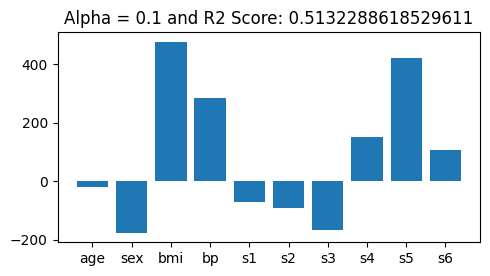

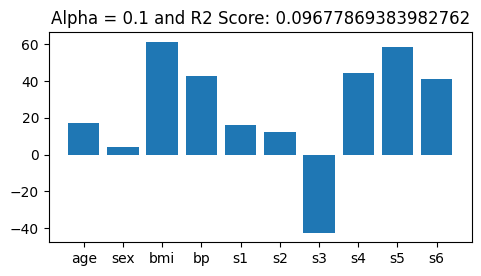

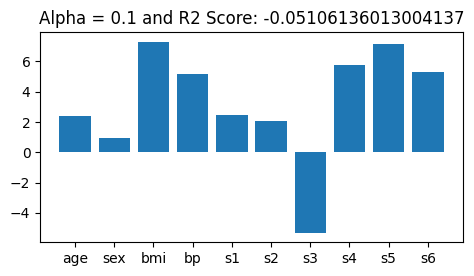

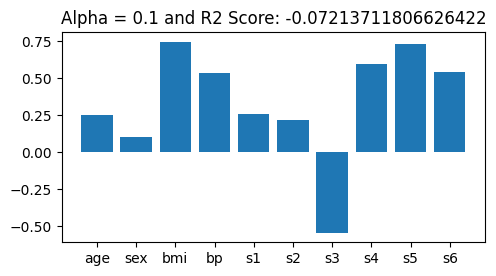

In [31]:
plt.figure(figsize=(12,6))
plt.subplot(221)
plt.bar(data.feature_names , coeff[0])
plt.title(f"Alpha = 0.1 and R2 Score: {r2Score[0]}")

plt.figure(figsize=(12,6))
plt.subplot(222)
plt.bar(data.feature_names , coeff[1])
plt.title(f"Alpha = 0.1 and R2 Score: {r2Score[1]}")

plt.figure(figsize=(12,6))
plt.subplot(223)
plt.bar(data.feature_names , coeff[2])
plt.title(f"Alpha = 0.1 and R2 Score: {r2Score[2]}")

plt.figure(figsize=(12,6))
plt.subplot(224)
plt.bar(data.feature_names , coeff[3])
plt.title(f"Alpha = 0.1 and R2 Score: {r2Score[3]}")

### 2. The more the value of coefficient the more they will decrease while alpha increase

In [56]:
from sklearn.linear_model import RidgeCV

alphas =[0.1 , 1 , 5 , 10 , 15 , 50 ]

ridge_cv = RidgeCV(alphas,cv=5)
ridge_cv.fit(X_train , y_train)

ridge_cv.alpha_

np.float64(0.1)

In [57]:
coeff = []
r2Score = []

for i in alphas:
    rg = Ridge(alpha=i)
    rg.fit(X_train , y_train)
    coeff.append(rg.coef_.tolist())
    r2Score.append(r2_score(y_test , rg.predict(X_test)))

In [58]:
input_arry = np.array(coeff).T
input_arry.shape

(10, 6)

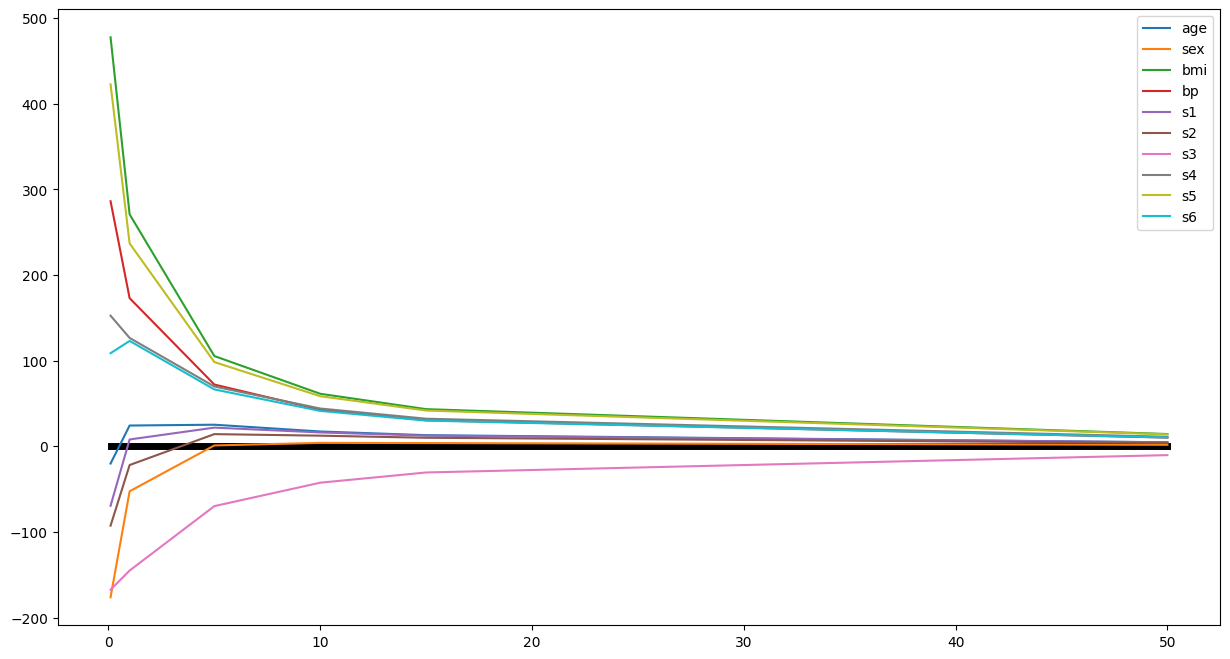

In [59]:
plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color="black",linewidth=5)
for i in range(input_arry.shape[0]):
    plt.plot(alphas,input_arry[i], label=data.feature_names[i])

plt.legend()